# Demo web dùng mô hình phân loại nhạc

In [1]:
import tensorflow as tf
try:
    import keras
except Exception:
    keras = None
print("tensorflow:", tf.__version__)
print("keras:", getattr(keras, "__version__", None))

tensorflow: 2.18.0
keras: 3.8.0


In [1]:
import sys
import numpy

# === (VÁ LỖI NUMPY) ===
try:
    sys.modules['numpy._core'] = numpy.core
    sys.modules['numpy._core.multiarray'] = numpy.core.multiarray
    sys.modules['numpy._core.numeric'] = numpy.core.numeric
except Exception:
    pass

import os
import io
import pickle
import traceback
from flask import send_file
import tensorflow as tf
from flask import Flask, request, jsonify, render_template, send_from_directory
import librosa
import numpy as np
import warnings
import matplotlib
matplotlib.use('Agg') # Backend không GUI để chạy trên server
import matplotlib.pyplot as plt
import gc
from sklearn.preprocessing import MinMaxScaler 

warnings.filterwarnings('ignore')

# === CẤU HÌNH ===
print(">>> Cấu hình TensorFlow...")
try:
    gpus = tf.config.experimental.list_physical_devices('GPU')
    if gpus:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
except Exception as e: print(f"Lỗi GPU: {e}")

# === LOAD MODEL & SCALER ===
print(">>> Đang tải Resources...")
# !!! ĐƯỜNG DẪN TUYỆT ĐỐI (HÃY KIỂM TRA LẠI TRÊN MÁY BẠN) !!!
MODEL_PATH = r'D:\Python_mohinh\Mohinh\KQ_Thu_Nghiem_8\MODEL_2STAGE_v10_Fusion_FMA_ONLY_Chunks3_FINAL.keras'
SCALER_PATH = r'D:\Python_mohinh\scaler_60_features_fixed.pkl'

try:
    model = tf.keras.models.load_model(MODEL_PATH)
    print(">>> Load Model OK!")
except Exception as e: print(f"!!! LỖI MODEL: {e}")

scaler = None
try:
    with open(SCALER_PATH, 'rb') as f:
        scaler = pickle.load(f)
    print(f">>> Load Scaler OK! (Mean shape: {scaler.mean_.shape})")
except Exception as e:
    print(f"!!! LỖI SCALER: {e}")
    scaler = None

# CONSTANTS
NUM_AUDIO_FEATURES = 60
class_names = ['Electronic', 'Experimental', 'Folk', 'Hip-Hop', 'Instrumental', 'International', 'Pop', 'Rock']
IMG_HEIGHT = 128; IMG_WIDTH = 431 
DURATION = 10; HOP_LENGTH = 512; N_MFCC = 20
SAMPLES_NEEDED = 220500
ADJUSTMENT_WEIGHTS = np.array([1.0] * 8)

# Warm-up
try:
    model.predict([np.zeros((1, 128, 431, 3)), np.zeros((1, 60))])
    print(">>> Warm-up OK!")
except: pass

# ================== CÁC HÀM XỬ LÝ ==================
def read_audio(path):
    try:
        y, sr = librosa.load(path, mono=True, sr=22050, duration=DURATION)
        if len(y) < SAMPLES_NEEDED: y = np.pad(y, (0, SAMPLES_NEEDED - len(y)))
        else: y = y[:SAMPLES_NEEDED]
        return y, 22050
    except Exception as e:
        print(f"Lỗi đọc audio: {e}")
        return None, None

def create_spectrogram_array(y, sr):
    try:
        spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=IMG_HEIGHT, hop_length=HOP_LENGTH, fmax=8000)
        spec_db = librosa.power_to_db(spec, ref=np.max)
        if spec_db.shape[1] < IMG_WIDTH: spec_db = np.pad(spec_db, ((0,0), (0, IMG_WIDTH-spec_db.shape[1])))
        else: spec_db = spec_db[:, :IMG_WIDTH]
        return np.stack((spec_db,)*3, axis=-1).astype("float32")
    except: return None

def extract_vector_60(y, sr):
    try:
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC, hop_length=HOP_LENGTH)
        chroma = librosa.feature.chroma_cqt(y=y, sr=sr, hop_length=HOP_LENGTH)
        cent = librosa.feature.spectral_centroid(y=y, sr=sr, hop_length=HOP_LENGTH)
        bw = librosa.feature.spectral_bandwidth(y=y, sr=sr, hop_length=HOP_LENGTH)
        roll = librosa.feature.spectral_rolloff(y=y, sr=sr, hop_length=HOP_LENGTH)
        zcr = librosa.feature.zero_crossing_rate(y=y, hop_length=HOP_LENGTH)
        rms = librosa.feature.rms(y=y, hop_length=HOP_LENGTH)
        cont = librosa.feature.spectral_contrast(y=y, sr=sr, hop_length=HOP_LENGTH)
        flat = librosa.feature.spectral_flatness(y=y, hop_length=HOP_LENGTH)
        cens = librosa.feature.chroma_cens(y=y, sr=sr, hop_length=HOP_LENGTH)
        poly = librosa.feature.poly_features(y=y, sr=sr, order=2, hop_length=HOP_LENGTH)
        
        feats = np.vstack([mfcc, chroma, cent, bw, roll, zcr, rms, cont, flat, cens, poly])
        vec_raw = np.mean(feats, axis=1)
        
        if scaler:
            return scaler.transform(vec_raw.reshape(1, -1)).flatten().astype("float32")
        return vec_raw.astype("float32")
    except: return None

# Hàm vẽ Sequence (cho route /audio_features)
def extract_sequence_for_plot(y, sr):
    try:
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC, hop_length=HOP_LENGTH)
        chroma = librosa.feature.chroma_cqt(y=y, sr=sr, hop_length=HOP_LENGTH)
        # ... (Lấy đại diện vài feature để vẽ cho nhẹ)
        cent = librosa.feature.spectral_centroid(y=y, sr=sr, hop_length=HOP_LENGTH)
        cont = librosa.feature.spectral_contrast(y=y, sr=sr, hop_length=HOP_LENGTH)
        
        feats = np.vstack([mfcc, chroma, cent, cont]) # Vẽ ít thôi cho đẹp
        
        # Transpose để trục hoành là thời gian
        return feats.T 
    except: return None

# ================== FLASK APP ==================
app = Flask(__name__)

@app.route("/")
def index(): return send_from_directory('.', 'index.html')

@app.route('/<path:filename>')
def static_files(filename): return send_from_directory('.', filename)

# API: DỰ ĐOÁN
@app.route("/predict", methods=['POST'])
def predict():
    files = request.files.getlist('file')
    if not files: return jsonify({"error": "No file"}), 400
    
    imgs, vecs, names, paths = [], [], [], []
    
    try:
        for i, f in enumerate(files):
            path = f"temp_{i}.mp3"
            f.save(path)
            paths.append(path)
            
            y, sr = read_audio(path)
            if y is None: continue
            
            img = create_spectrogram_array(y, sr)
            vec = extract_vector_60(y, sr)
            
            if img is not None and vec is not None:
                imgs.append(img)
                vecs.append(vec)
                names.append(f.filename)
        
        if not imgs: return jsonify({"error": "Failed all files"}), 500
        
        preds = model.predict([np.array(imgs), np.array(vecs)])
        
        results = []
        for i, prob in enumerate(preds):
            prob = prob * ADJUSTMENT_WEIGHTS
            prob = prob / np.sum(prob)
            idx = np.argmax(prob)
            results.append({
                "file_name": names[i],
                "genre_du_doan": class_names[idx],
                "do_tin_cay": f"{np.max(prob)*100:.2f}%",
                "all_scores": {k: float(v) for k,v in zip(class_names, prob)}
            })
        return jsonify(results)
        
    except Exception as e: 
        traceback.print_exc()
        return jsonify({"error": str(e)}), 500
    finally:
        for p in paths: 
            if os.path.exists(p): os.remove(p)
        gc.collect()

# API: ẢNH SPECTROGRAM (Bị thiếu ở code cũ -> Đã thêm lại)
@app.route("/spectrogram", methods=['POST'])
def spectrogram():
    f = request.files.getlist('file')[0]
    path = "temp_spec.mp3"
    try:
        f.save(path)
        y, sr = read_audio(path)
        
        # Vẽ ảnh
        spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
        spec_db = librosa.power_to_db(spec, ref=np.max)
        
        fig = plt.figure(figsize=(10, 3))
        plt.imshow(spec_db, aspect='auto', origin='lower', cmap='magma')
        plt.axis('off')
        plt.tight_layout(pad=0)
        
        buf = io.BytesIO()
        plt.savefig(buf, format='png')
        buf.seek(0)
        plt.close(fig)
        
        return send_file(buf, mimetype='image/png')
    except Exception as e: return jsonify({"error": str(e)}), 500
    finally: 
        if os.path.exists(path): os.remove(path)

# API: ẢNH ĐẶC TRƯNG (Bị thiếu ở code cũ -> Đã thêm lại)
@app.route("/audio_features", methods=['POST'])
def features_plot():
    f = request.files.getlist('file')[0]
    path = "temp_feat.mp3"
    try:
        f.save(path)
        y, sr = read_audio(path)
        feats = extract_sequence_for_plot(y, sr)
        
        # Chuẩn hóa để vẽ đẹp
        scaler_plot = MinMaxScaler()
        feats_norm = scaler_plot.fit_transform(feats).T
        
        fig = plt.figure(figsize=(10, 3))
        plt.imshow(feats_norm, aspect='auto', origin='lower', cmap='viridis')
        plt.axis('off')
        plt.tight_layout(pad=0)
        
        buf = io.BytesIO()
        plt.savefig(buf, format='png')
        buf.seek(0)
        plt.close(fig)
        
        return send_file(buf, mimetype='image/png')
    except Exception as e: return jsonify({"error": str(e)}), 500
    finally: 
        if os.path.exists(path): os.remove(path)

if __name__ == "__main__":
    print(">>> Đang khởi động Server trên cổng 5050...")
    # use_reloader=False là BẮT BUỘC khi chạy trên Notebook/Colab
    # Đổi port sang 5050 để tránh lỗi "Address already in use"
    app.run(debug=True, use_reloader=False, port=5050, host='0.0.0.0')

: 

In [6]:
import os
import librosa
import numpy as np
import pickle
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
import warnings

# Tắt cảnh báo
warnings.filterwarnings('ignore')

# ================= CẤU HÌNH =================
# 1. Đường dẫn thư mục gốc (Nó sẽ tự tìm trong 000, 001...)
MUSIC_DATASET_PATH = r"D:\Python_mohinh\data\FMA_Small\fma_small\fma_small"

# 2. Số lượng bài hát lấy mẫu (Tăng lên 2000 cho chuẩn)
SAMPLE_SIZE = 7000

# 3. Tên file xuất ra
OUTPUT_SCALER_NAME = 'scaler_60_features_fixed.pkl'

# 4. Cấu hình Âm thanh (KHỚP VỚI APP.PY)
DURATION = 10 
HOP_LENGTH = 512
N_MFCC = 20

# ================= HÀM TRÍCH XUẤT =================
def extract_features_strict(file_path):
    try:
        # Load Audio
        y, sr = librosa.load(file_path, mono=True, sr=22050, duration=DURATION)
        
        # Padding
        needed = 22050 * DURATION
        if len(y) < needed: y = np.pad(y, (0, needed - len(y)), 'constant')
        else: y = y[:needed]

        # Trích xuất 57 đặc trưng cơ bản
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC, hop_length=HOP_LENGTH)
        chroma = librosa.feature.chroma_cqt(y=y, sr=sr, hop_length=HOP_LENGTH)
        spec_cent = librosa.feature.spectral_centroid(y=y, sr=sr, hop_length=HOP_LENGTH)
        spec_bw = librosa.feature.spectral_bandwidth(y=y, sr=sr, hop_length=HOP_LENGTH)
        rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr, hop_length=HOP_LENGTH)
        zcr = librosa.feature.zero_crossing_rate(y=y, hop_length=HOP_LENGTH)
        rms = librosa.feature.rms(y=y, hop_length=HOP_LENGTH)
        spec_contrast = librosa.feature.spectral_contrast(y=y, sr=sr, hop_length=HOP_LENGTH)
        spec_flatness = librosa.feature.spectral_flatness(y=y, hop_length=HOP_LENGTH)
        chroma_cens = librosa.feature.chroma_cens(y=y, sr=sr, hop_length=HOP_LENGTH)
        
        # Poly Features (3 cái) -> Tổng 60
        poly_features = librosa.feature.poly_features(y=y, sr=sr, order=2, hop_length=HOP_LENGTH)

        all_features = np.vstack([
            mfcc, chroma, spec_cent, spec_bw, rolloff, zcr, rms, 
            spec_contrast, spec_flatness, chroma_cens, poly_features
        ])
        
        # Tính Mean
        return np.mean(all_features, axis=1)
        
    except Exception:
        return None

# ================= MAIN =================
def main():
    print(f">>> Đang quét thư mục: {MUSIC_DATASET_PATH}")
    
    mp3_files = []
    # Quét đệ quy (Recursive) vào các thư mục con 000, 001...
    for root, dirs, files in os.walk(MUSIC_DATASET_PATH):
        for file in files:
            if file.lower().endswith('.mp3'):
                mp3_files.append(os.path.join(root, file))
                # Chỉ lấy đủ số lượng cần thiết rồi dừng tìm kiếm cho nhanh
                if len(mp3_files) >= SAMPLE_SIZE:
                    break
        if len(mp3_files) >= SAMPLE_SIZE:
            break
            
    print(f">>> Đã tìm thấy {len(mp3_files)} bài hát để lấy mẫu.")
    
    if len(mp3_files) == 0:
        print("!!! LỖI: Không tìm thấy file nhạc. Kiểm tra lại đường dẫn.")
        return

    print(">>> Bắt đầu trích xuất đặc trưng (Sẽ mất vài phút)...")
    collected_vectors = []
    
    for file_path in tqdm(mp3_files):
        vec = extract_features_strict(file_path)
        if vec is not None and vec.shape == (60,):
            collected_vectors.append(vec)

    print(f">>> Hoàn tất trích xuất. Số mẫu hợp lệ: {len(collected_vectors)}")

    if len(collected_vectors) > 0:
        print(">>> Đang tính toán thống kê (Fit Scaler)...")
        scaler = StandardScaler()
        scaler.fit(np.array(collected_vectors)) # Tính Mean/Std
        
        # Lưu file
        with open(OUTPUT_SCALER_NAME, 'wb') as f:
            pickle.dump(scaler, f)
            
        print("\n" + "="*50)
        print(f"✅ ĐÃ TẠO SCALER: {OUTPUT_SCALER_NAME}")
        print(f"✅ Dựa trên: {len(collected_vectors)} bài hát.")
        print(f"✅ Kích thước vector: {scaler.mean_.shape} (Chuẩn 60!)")
        print("="*50)
        print(">>> BƯỚC CUỐI: Sửa SCALER_PATH trong app.py thành tên file này.")
    else:
        print("!!! Lỗi: Không trích xuất được dữ liệu nào.")

if __name__ == "__main__":
    main()

>>> Đang quét thư mục: D:\Python_mohinh\data\FMA_Small\fma_small\fma_small
>>> Đã tìm thấy 7000 bài hát để lấy mẫu.
>>> Bắt đầu trích xuất đặc trưng (Sẽ mất vài phút)...


100%|██████████| 7000/7000 [1:11:28<00:00,  1.63it/s]

>>> Hoàn tất trích xuất. Số mẫu hợp lệ: 6997
>>> Đang tính toán thống kê (Fit Scaler)...

✅ ĐÃ TẠO SCALER: scaler_60_features_fixed.pkl
✅ Dựa trên: 6997 bài hát.
✅ Kích thước vector: (60,) (Chuẩn 60!)
>>> BƯỚC CUỐI: Sửa SCALER_PATH trong app.py thành tên file này.


# Phần bài tập trên lớp (Không liên quan)

Phiên bản TensorFlow: 2.18.0

Bắt đầu huấn luyện Bài 9.1 (700 epochs)...
Hoàn thành huấn luyện.
Độ chính xác trên tập huấn luyện: 100.00%
Đang vẽ biểu đồ ranh giới quyết định...
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 805us/step


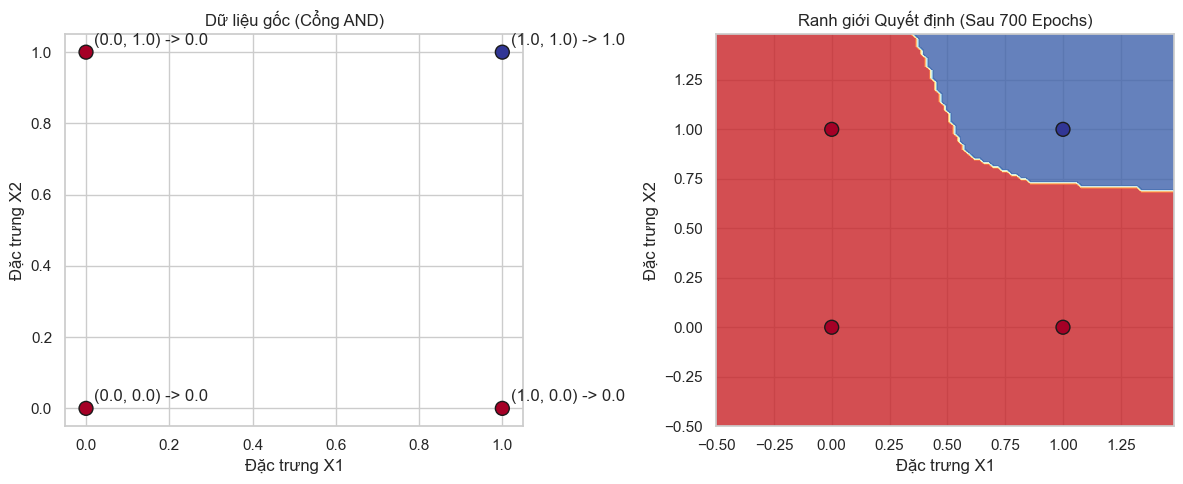

In [18]:
# Buổi 9 - Bài 9.1: Huấn luyện mô hình 300 epochs VÀ Trực quan hóa

%matplotlib inline
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt  # Thêm thư viện này

print(f"Phiên bản TensorFlow: {tf.__version__}")

# --- 1. Tạo Dữ liệu ---
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=float)
y = np.array([0, 0, 0, 1], dtype=float) # Kết quả của cổng AND

# --- 2. Xây dựng Mô hình ---
model_1 = Sequential()
model_1.add(Dense(8, input_dim=2, activation='relu'))
model_1.add(Dense(1, activation='sigmoid'))

# --- 3. Compile Mô hình ---
model_1.compile(optimizer='adam', 
                loss='binary_crossentropy', 
                metrics=['accuracy'])

# --- 4. Huấn luyện Mô hình (300 EPOCHS) ---
print("\nBắt đầu huấn luyện Bài 9.1 (700 epochs)...")
# Sử dụng 300 epochs từ code huấn luyện của bạn
model_1.fit(X, y, epochs=700, verbose=0) 

# --- 5. Đánh giá Mô hình ---
loss, accuracy = model_1.evaluate(X, y, verbose=0)
print(f"Hoàn thành huấn luyện.")
print(f"Độ chính xác trên tập huấn luyện: {accuracy * 100:.2f}%")

# --- 6. Trực quan hóa (Lấy từ code 1) ---
print("Đang vẽ biểu đồ ranh giới quyết định...")
plt.figure(figsize=(12, 5))

# --- Ô 1: Dữ liệu gốc ---
plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu, s=100, edgecolors='k')
plt.title("Dữ liệu gốc (Cổng AND)")
plt.xlabel("Đặc trưng X1")
plt.ylabel("Đặc trưng X2")
for i, txt in enumerate(y):
    plt.annotate(f"({X[i][0]}, {X[i][1]}) -> {txt}", (X[i][0]+0.02, X[i][1]+0.02))

# --- Ô 2: Ranh giới Quyết định (của mô hình 300 epochs) ---
plt.subplot(1, 2, 2)
h = .02
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Sử dụng chính model_1 vừa huấn luyện 300 epochs để dự đoán
Z = model_1.predict(np.c_[xx.ravel(), yy.ravel()])
Z = (Z > 0.5).astype(int)
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, cmap=plt.cm.RdYlBu, alpha=0.8)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu, s=100, edgecolors='k')
plt.title("Ranh giới Quyết định (Sau 700 Epochs)")
plt.xlabel("Đặc trưng X1")
plt.ylabel("Đặc trưng X2")

plt.tight_layout()
plt.show()

Phiên bản TensorFlow: 2.18.0

Đang vẽ biểu đồ khám phá (EDA)...


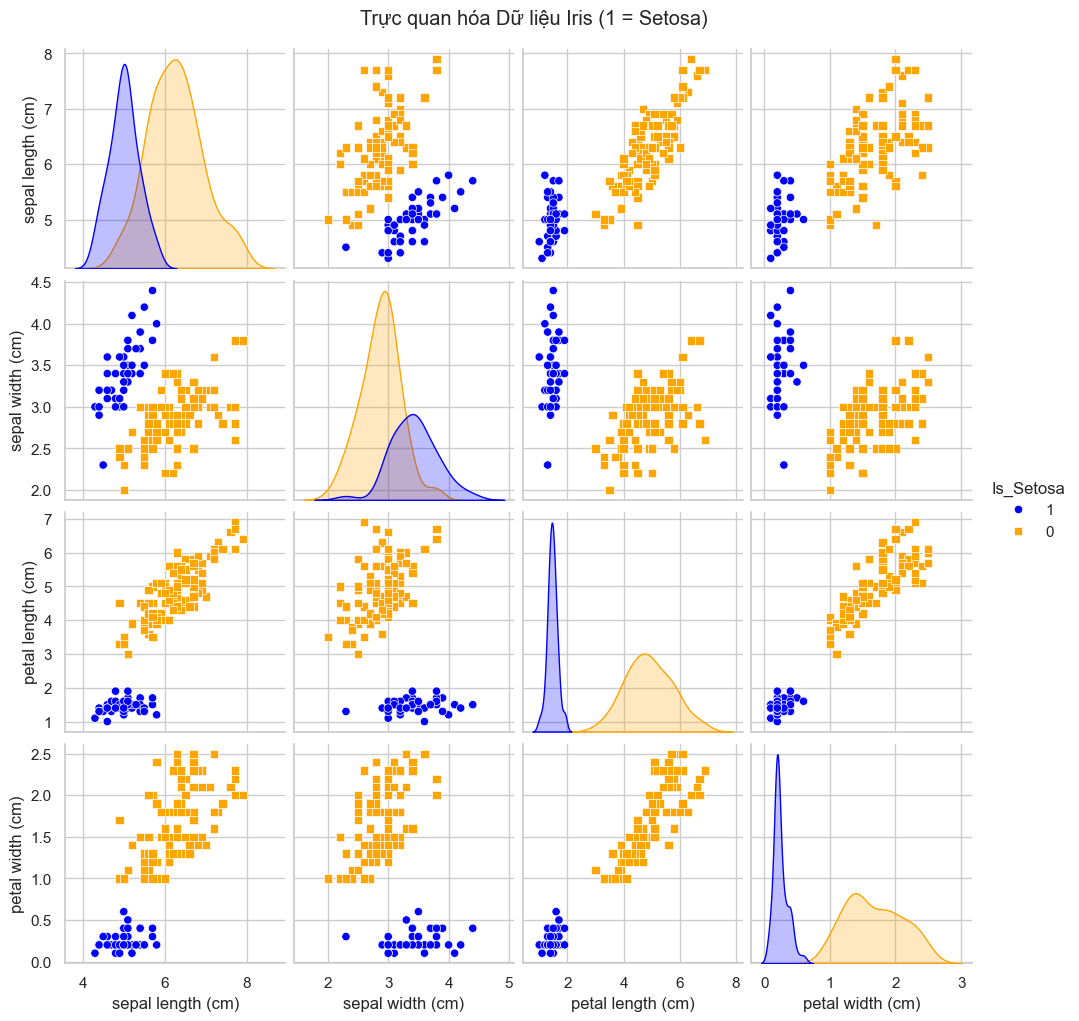

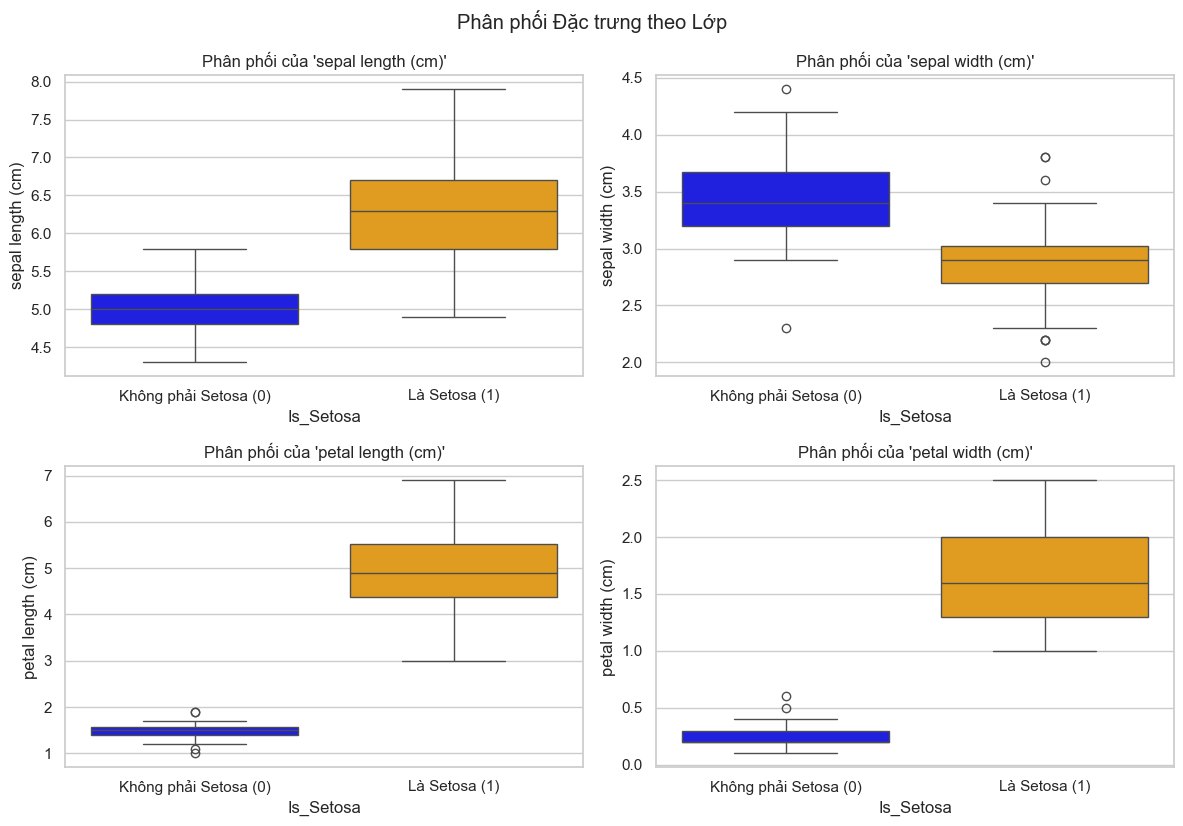


Bắt đầu xây dựng và huấn luyện mô hình...
Hoàn thành huấn luyện.

--- Kết quả Đánh giá trên Tập kiểm tra ---
Độ chính xác: 100.00%
Loss: 0.0046

Đang vẽ lịch sử huấn luyện...


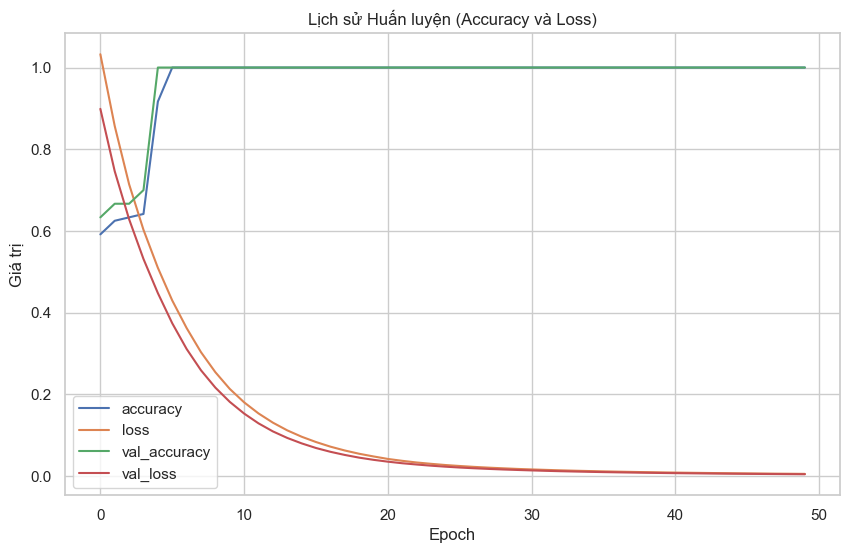

In [19]:
# Buổi 9 - Bài 9.2: Gộp Trực quan hóa và Huấn luyện Mô hình
# LOGIC THỐNG NHẤT: 1 = Là Setosa, 0 = Không phải Setosa

%matplotlib inline

# --- 1. IMPORT CÁC THƯ VIỆN CẦN THIẾT ---
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print(f"Phiên bản TensorFlow: {tf.__version__}")

# --- 2. TẢI VÀ CHUẨN BỊ DỮ LIỆU ---
iris = load_iris()
X = iris.data
# Sử dụng logic thống nhất: 1 = Setosa, 0 = Không phải Setosa
y_binary = (iris.target == 0).astype(int) 

# --- 3. TRỰC QUAN HÓA KHÁM PHÁ (EDA) ---
print("\nĐang vẽ biểu đồ khám phá (EDA)...")
df_viz = pd.DataFrame(data=X, columns=iris.feature_names)
df_viz['Is_Setosa'] = y_binary.astype(str) # Chuyển sang string để seaborn không lỗi

# 3.1. Pair Plot
sns.pairplot(df_viz, 
             vars=iris.feature_names, 
             hue='Is_Setosa', 
             palette={'0': 'orange', '1': 'blue'}, # 0: Không, 1: Là Setosa
             markers=["o", "s"]) 
plt.suptitle("Trực quan hóa Dữ liệu Iris (1 = Setosa)", y=1.02)
plt.show()

# 3.2. Box Plot
plt.figure(figsize=(12, 8))
for i, feature in enumerate(iris.feature_names):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(data=df_viz, x='Is_Setosa', y=feature, palette={'0': 'orange', '1': 'blue'})
    plt.title(f"Phân phối của '{feature}'")
    plt.xticks([0, 1], ['Không phải Setosa (0)', 'Là Setosa (1)'])
plt.tight_layout()
plt.suptitle("Phân phối Đặc trưng theo Lớp", y=1.03)
plt.show()

# --- 4. CHUẨN BỊ DỮ LIỆU CHO MÔ HÌNH ---
# 4.1. Chuẩn hóa X
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4.2. Chia dữ liệu (sử dụng y_binary đã thống nhất)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_binary, test_size=0.2, random_state=42)

# --- 5. XÂY DỰNG VÀ HUẤN LUYỆN MÔ HÌNH ---
print("\nBắt đầu xây dựng và huấn luyện mô hình...")
model_2 = Sequential()
model_2.add(Dense(16, input_dim=4, activation='relu')) # Tầng ẩn 1
model_2.add(Dense(8, activation='relu'))              # Tầng ẩn 2
model_2.add(Dense(1, activation='sigmoid'))           # Tầng đầu ra

model_2.compile(optimizer='adam',
                loss='binary_crossentropy',
                metrics=['accuracy'])

# 5.1. Huấn luyện
history = model_2.fit(X_train, y_train, 
                      epochs=50, 
                      batch_size=8, 
                      validation_data=(X_test, y_test), 
                      verbose=0) # verbose=0 để ẩn log

print("Hoàn thành huấn luyện.")

# --- 6. ĐÁNH GIÁ MÔ HÌNH ---
# 6.1. Đánh giá bằng số liệu
loss, accuracy = model_2.evaluate(X_test, y_test, verbose=0)
print(f"\n--- Kết quả Đánh giá trên Tập kiểm tra ---")
print(f"Độ chính xác: {accuracy * 100:.2f}%")
print(f"Loss: {loss:.4f}")

# 6.2. Trực quan hóa Lịch sử Huấn luyện (Training History)
print("\nĐang vẽ lịch sử huấn luyện...")
pd.DataFrame(history.history).plot(figsize=(10, 6))
plt.grid(True)
plt.title("Lịch sử Huấn luyện (Accuracy và Loss)")
plt.xlabel("Epoch")
plt.ylabel("Giá trị")
plt.show()